<a href="https://colab.research.google.com/github/Williantx/P-s-Tech-Data-Analytics/blob/main/Tech_Challenge_Fase2_IBOVESPA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tech Challenge Fase 2 — Previsão do Fechamento do IBOVESPA

**Objetivo:** construir uma estratégia de dados completa para prever o fechamento diário do IBOVESPA, com **assertividade mínima de 80%**, apresentando storytelling e justificativa técnica das escolhas.

**Dados:** [Investing.com — Bovespa Historical Data](https://br.investing.com/indices/bovespa-historical-data), 2010 a 2026.

## Como definimos "assertividade" neste projeto

O IBOVESPA é uma série temporal financeira muito próxima de um **passeio aleatório** (random walk): o valor de amanhã costuma ser muito parecido com o valor de hoje, e variações diárias acima de 2% são raras. Isso tem duas consequências importantes para a estratégia:

1. **Prever o valor de fechamento (regressão)** é uma tarefa em que até um modelo ingênuo (repetir o valor de ontem) já acerta com erro percentual baixo, porque o preço não costuma variar muito de um dia para o outro. Definimos **assertividade = 1 − WMAPE** (Weighted Mean Absolute Percentage Error). Vamos mostrar que essa meta de 80% é atingível , mas também deixaremos claro quando um bom resultado nessa métrica não significa necessariamente uma previsão útil para decisão de investimento.
2. **Prever a direção do próximo pregão (alta ou baixa)** é uma tarefa diferente e muito mais difícil — é o que de fato importaria para decisões de investimento. Testamos essa abordagem também, de forma transparente, para enriquecer o storytelling e mostrar os limites reais de "bater o mercado".

A entrega formal (≥80% de assertividade) é resolvida pela via de **regressão com validação temporal correta**; a via de **classificação de direção** entra como uma camada extra de investigação e senso crítico, deixando o projeto mais robusto.

## Roteiro do notebook (mapeado aos itens exigidos no enunciado)

1. Leitura e limpeza dos dados
2. **Storytelling** — análise exploratória e contexto histórico dos picos de alta e baixa
3. **Decomposição da série temporal** e teste de estacionariedade
4. Engenharia de atributos (features)
5. Separação treino/teste (respeitando a ordem temporal)
6. Modelo baseline (Naive)
7. **Modelo utilizado (ARIMA) — explicação e vantagens**
8. Modelos de regressão com features (Linear, Random Forest, XGBoost) — comparação
9. Modelos de classificação de direção (investigação complementar / senso crítico)
10. **Demonstração de resultados com métricas estatísticas** (comparação final e escolha do modelo)
11. **Predição dos próximos 15 dias**
12. Conclusão, limitações e próximos passos

## 1. Setup

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb

sns.set_style("whitegrid")

def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error"""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))

## 2. Leitura e limpeza dos dados

A base original tem **quatro inconsistências** que precisam ser corrigidas antes de qualquer modelagem:

1. Coluna `Data` como texto (formato dia/mês/ano);
2. `Var%` como texto, com vírgula decimal e símbolo `%`;
3. **`Vol.` mistura três unidades diferentes no mesmo texto: `K` (mil), `M` (milhão) e `B` (bilhão)** — o volume negociado cresceu tanto ao longo dos 16 anos que a própria fonte muda a unidade de medida conforme o período. Tratar isso ingenuamente (ex.: dividir por 1000 apenas os valores "grandes demais") gera uma série de volume distorcida, misturando milhões com bilhões.
4. Um único valor nulo em `Vol.`, que será removido (não compromete a representatividade da série, tratando-se de apenas uma linha).

In [41]:
path = 'dados_ibovespa_2010-2026.csv'
dados = pd.read_csv(path, parse_dates=[0], dayfirst=True)
dados.columns = ['ds', 'y', 'abertura', 'max', 'min', 'volume', 'variacao']

# Var%: vírgula -> ponto, remove '%'
dados['variacao'] = (dados['variacao'].astype(str)
                      .str.replace('%', '', regex=False)
                      .str.replace(',', '.', regex=False)
                      .astype(float))
# Volume: separa número da unidade (K/M/B) e normaliza tudo para MILHÕES de R$
def parse_volume(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip()
    unit = v[-1]
    num = v[:-1].replace(',', '.')
    mult = {'K': 1e3, 'M': 1e6, 'B': 1e9}.get(unit)
    if mult is None:
        return np.nan
    return float(num) * mult / 1e6

dados['volume'] = dados['volume'].apply(parse_volume)


# remove a única linha com volume nulo
dados = dados.dropna(subset=['volume']).copy()

# a base vem ordenada do mais recente para o mais antigo -> ordena ascendente (essencial p/ série temporal)
dados = dados.sort_values('ds').reset_index(drop=True)

print(f'Período: {dados.ds.min().date()} a {dados.ds.max().date()}  |  {len(dados)} pregões')
dados.head()

Período: 2010-01-04 a 2026-06-30  |  4088 pregões


,ds,y,abertura,max,min,volume,variacao
0,2010-01-04,70.045,68.587,70.081,68.587,1.66,2.12
1,2010-01-05,70.240,70.046,70.595,69.928,1.98,0.28
2,2010-01-06,70.729,70.236,70.937,70.016,2.24,0.70
3,2010-01-07,70.451,70.723,70.723,70.045,1.55,-0.39
4,2010-01-08,70.263,70.455,70.766,70.158,1.63,-0.27


## 3. Análise exploratória (EDA)

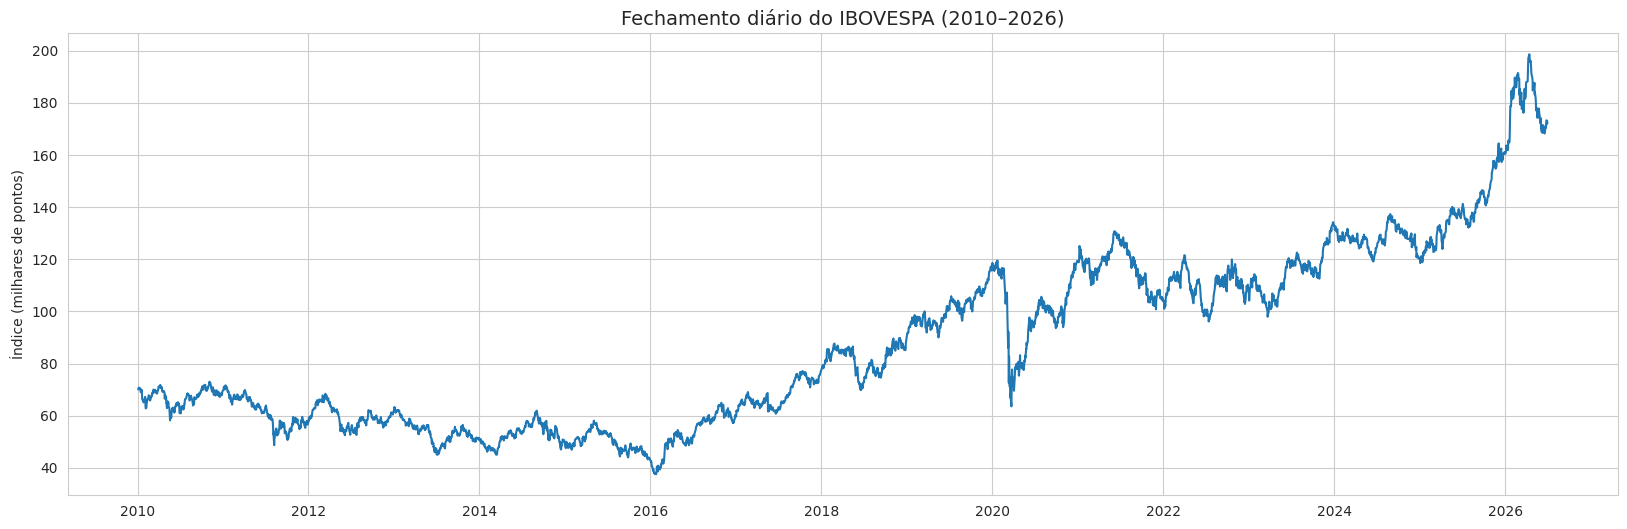

In [42]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.lineplot(dados, x='ds', y='y', ax=ax)
ax.set_title('Fechamento diário do IBOVESPA (2010–2026)', fontsize=14)
ax.set_ylabel('Índice (milhares de pontos)')
ax.set_xlabel('')
plt.show()

A série apresenta ciclos bem marcados: queda entre 2010 e 2016, forte alta entre 2016 e 2020, o choque da pandemia em 2020, e uma recuperação com novos ciclos de alta e baixa a partir de 2021, atingindo novos patamares em 2025–2026. Esse comportamento de longo prazo — tendências que duram anos, sem sazonalidade fixa — é típico de índices de bolsa e reforça que **modelos baseados em sazonalidade (ex: SeasonalNaive) não fazem sentido aqui**.

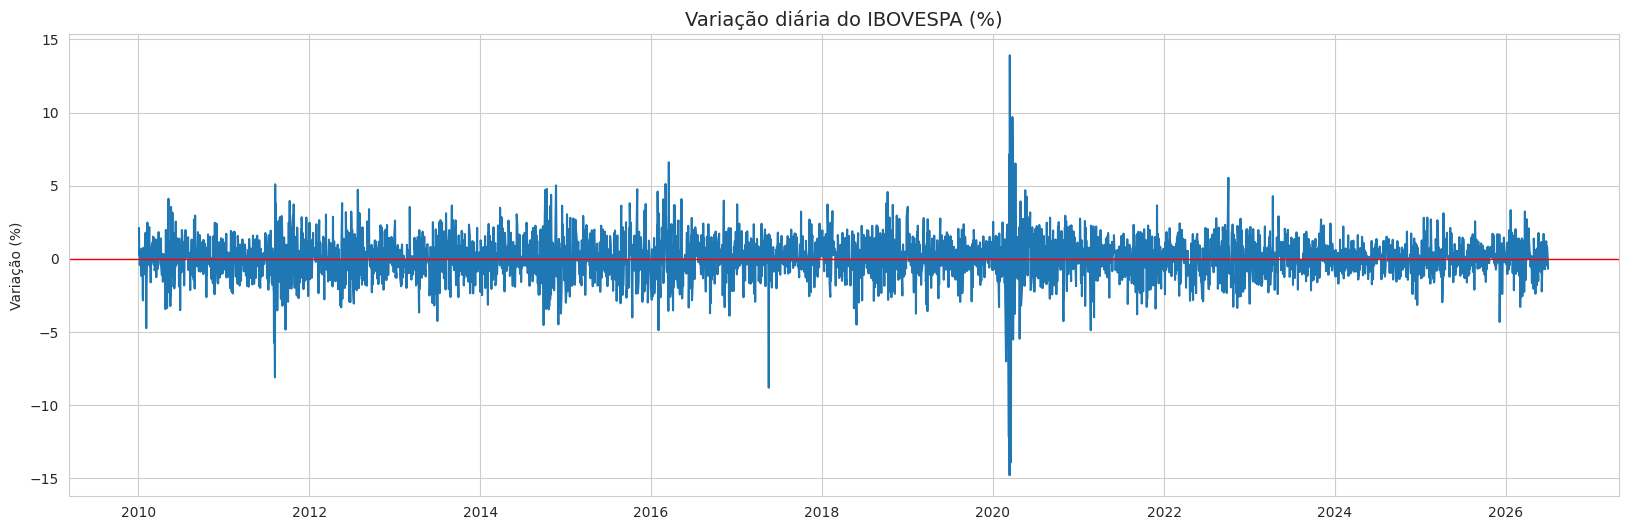

Maiores variações (%):
             ds  variacao
2520 2020-03-13     13.91
2527 2020-03-24      9.69
2528 2020-03-25      7.50

Menores variações (%):
             ds  variacao
2519 2020-03-12    -14.78
2521 2020-03-16    -13.92
2516 2020-03-09    -12.17


In [43]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.lineplot(dados, x='ds', y='variacao', ax=ax)
ax.axhline(y=0, color='red', linewidth=1)
ax.set_title('Variação diária do IBOVESPA (%)', fontsize=14)
ax.set_ylabel('Variação (%)')
ax.set_xlabel('')
plt.show()

print('Maiores variações (%):')
print(dados.nlargest(3, 'variacao')[['ds','variacao']])
print()
print('Menores variações (%):')
print(dados.nsmallest(3, 'variacao')[['ds','variacao']])

Os picos de maior volatilidade ocorrem, como esperado, em 2020 (choque da pandemia). A maioria dos dias, porém, se concentra entre -2% e +2% de variação um comportamento consistente com o que se espera de um índice amplo e líquido como o IBOVESPA.

**Contexto histórico dos principais ciclos de alta e baixa do IBOVESPA no período (storytelling):**

- **2010–2015:** tendência de queda e estagnação, associada à desaceleração da economia brasileira, deterioração fiscal e perda do grau de investimento do país.
- **2015–2016:** ponto de mínimo do período, no auge da crise política (processo de impeachment) e da recessão econômica — o pessimismo do mercado atinge o pico.
- **2016–2020:** forte tendência de alta, impulsionada pela reforma trabalhista, expectativa de reformas estruturais (previdência) e um cenário global de juros baixos que empurrou capital para mercados emergentes.
- **Fevereiro–março de 2020:** a maior e mais rápida queda do período, com os "circuit breakers" (paralisações do pregão) mais frequentes da história da B3, em razão do choque inicial da pandemia de Covid-19 — é exatamente aqui que aparecem as variações diárias extremas (+13,9% e -14,8%) observadas acima.
- **2020–2021:** recuperação em "V", puxada por estímulos monetários e fiscais em resposta à pandemia e pela migração de investidores de renda fixa para renda variável, com a Selic em mínimas históricas.
- **2021–2022:** novo ciclo de queda/lateralização, com o início do aperto monetário (alta da Selic) para conter a inflação pós-pandemia, somado à incerteza eleitoral.
- **2023–2026:** novo ciclo de recuperação e alta, refletindo o início do ciclo de corte de juros, fluxo de capital estrangeiro e resultados corporativos, levando o índice a patamares recordes ao final da série (acima de 170 mil pontos).

Esse pano de fundo macroeconômico e político é o que dá sentido às mudanças de regime identificadas na sériee reforça por que um modelo de séries temporais precisa ser **reavaliado periodicamente**: o comportamento estatístico do IBOVESPA muda de forma estrutural entre esses ciclos.

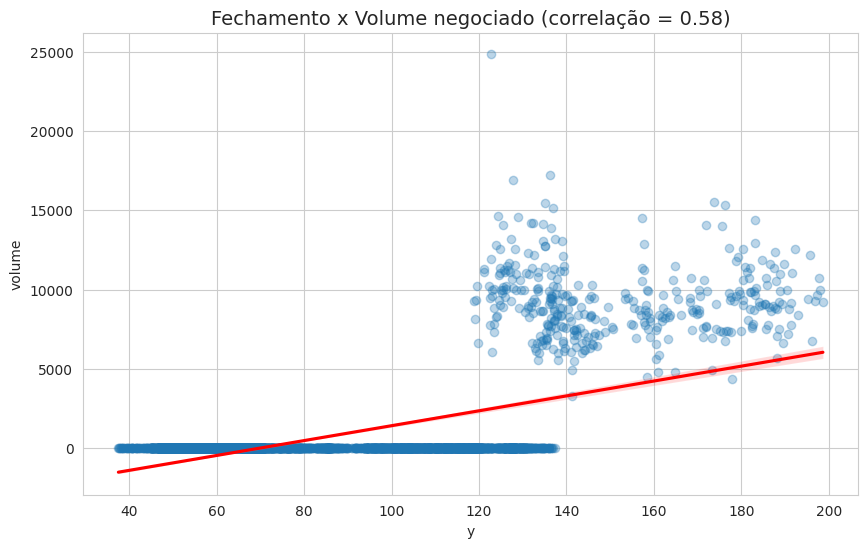

In [44]:
corr = dados[['y','volume']].corr().iloc[0,1]
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(dados, x='y', y='volume', ax=ax, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
ax.set_title(f'Fechamento x Volume negociado (correlação = {corr:.2f})', fontsize=14)
plt.show()

## 4. Decomposição da série temporal e estacionariedade

### 4.1 Decomposição (tendência, sazonalidade e resíduo)

Para decompor a série em seus componentes clássicos (tendência, sazonalidade e resíduo), primeiro precisamos de uma frequência regular — hoje a série só tem dias de pregão (sem fins de semana/feriados). Preenchemos essas lacunas com `ffill` (o valor do último pregão válido é repetido no fim de semana/feriado), apenas para viabilizar a decomposição — os modelos preditivos das próximas seções **não usam essa série preenchida**, apenas os dias de pregão reais.

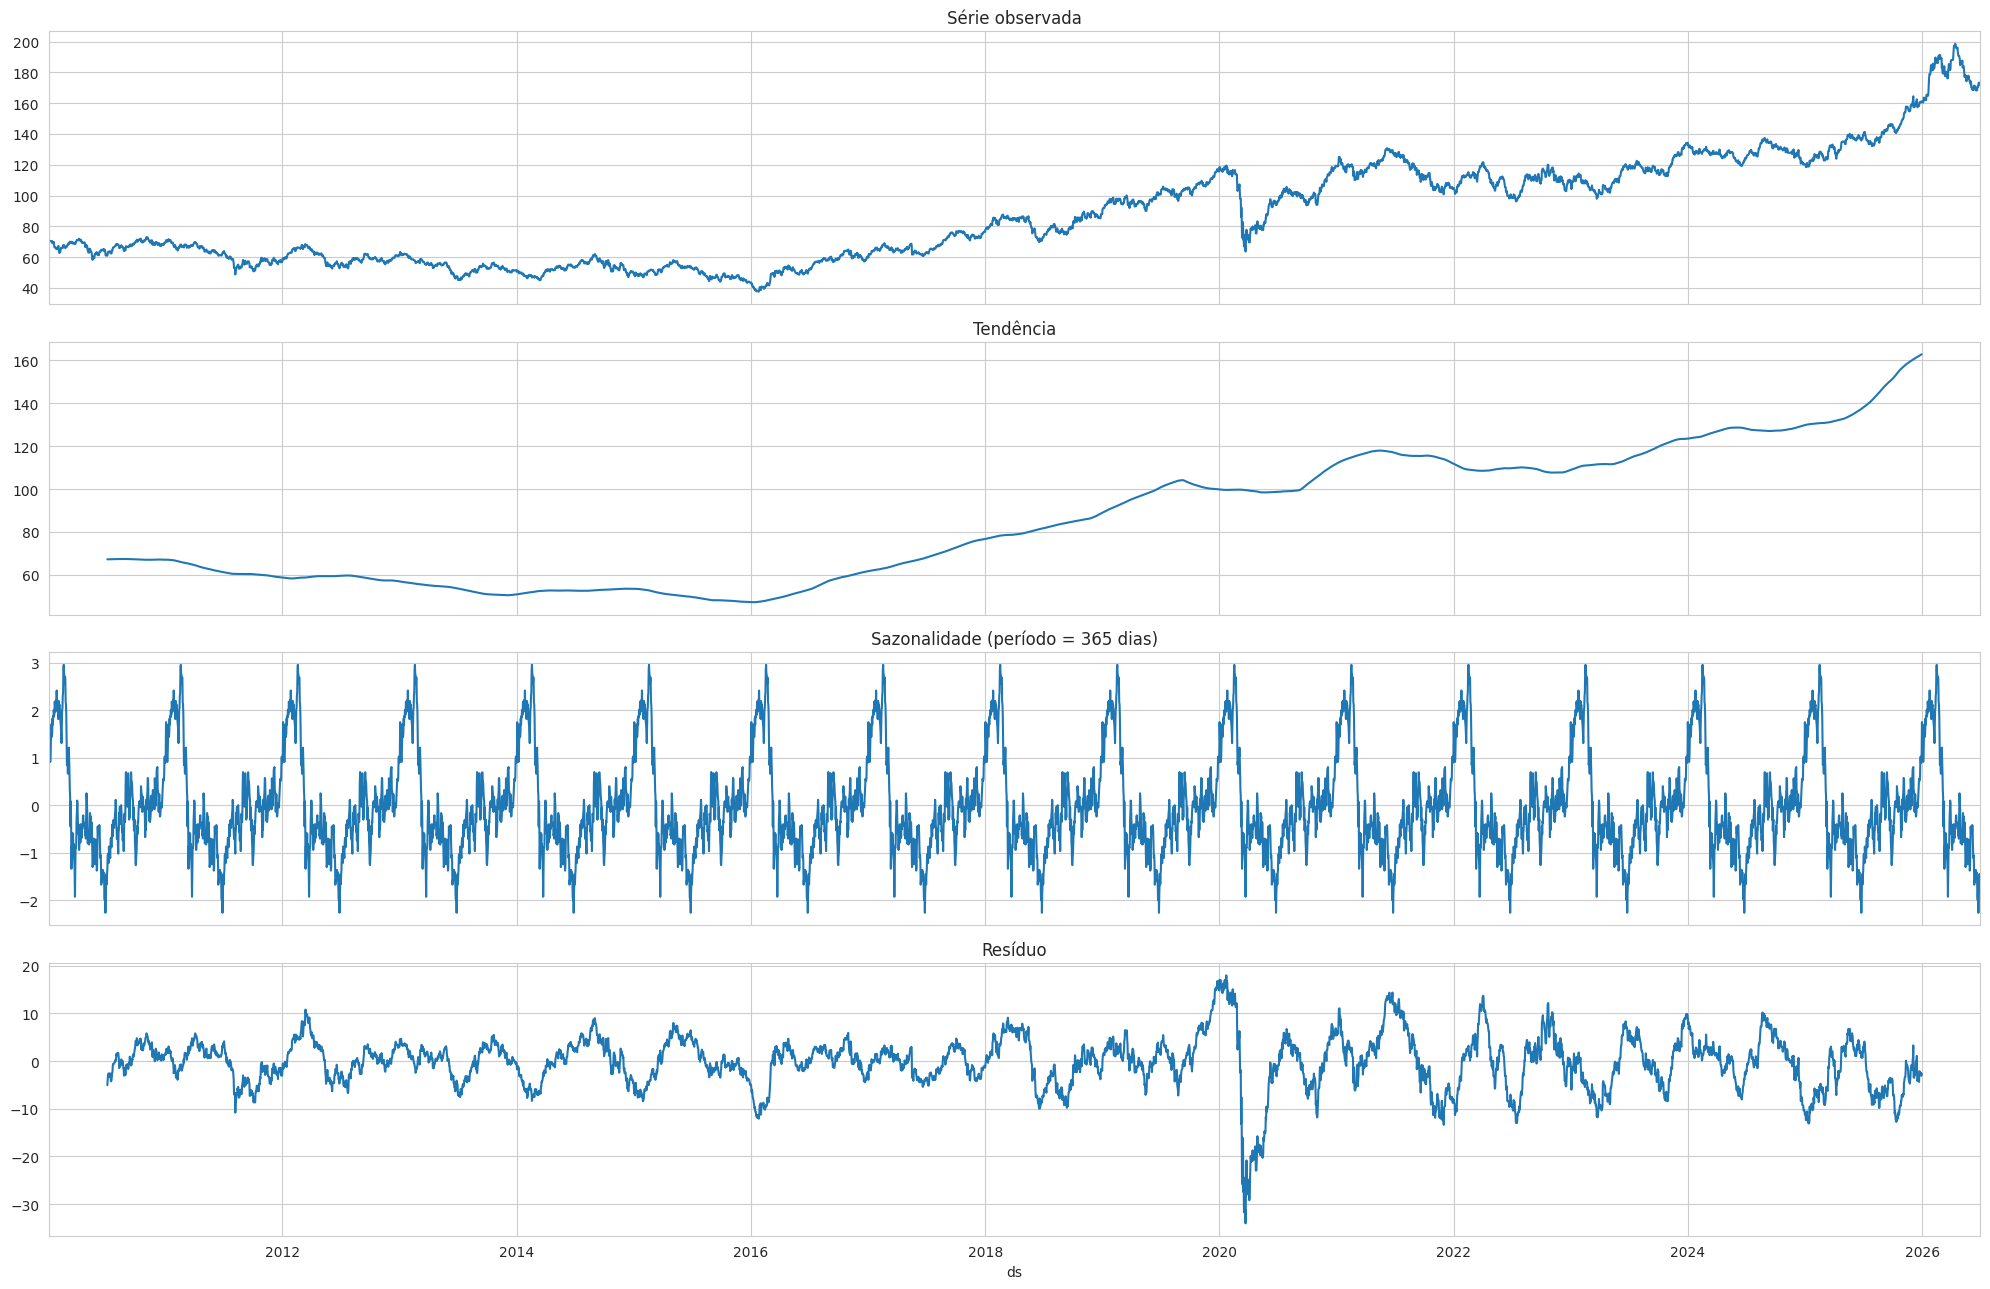

In [45]:
dados_diario = dados[['ds','y']].set_index('ds').asfreq('D').ffill()

decomposicao = seasonal_decompose(dados_diario['y'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(20, 13), sharex=True)
decomposicao.observed.plot(ax=axes[0]); axes[0].set_title('Série observada')
decomposicao.trend.plot(ax=axes[1]); axes[1].set_title('Tendência')
decomposicao.seasonal.plot(ax=axes[2]); axes[2].set_title('Sazonalidade (período = 365 dias)')
decomposicao.resid.plot(ax=axes[3]); axes[3].set_title('Resíduo')
plt.tight_layout()
plt.show()

**Leitura da decomposição:**

- **Tendência:** reproduz, de forma suavizada, os mesmos ciclos de alta e baixa plurianuais descritos no storytelling acima (queda até 2016, alta até 2020, choque da pandemia, nova alta até 2026). Isso confirma que o principal "motor" da série é a tendência de longo prazo, não um padrão sazonal.
- **Sazonalidade:** o componente sazonal anual tem amplitude pequena e um padrão que, embora o algoritmo force sua existência (toda decomposição clássica assume um ciclo), **não representa um efeito de calendário forte e confiável** é esperado, já que um índice de bolsa amplo não segue "estações do ano" fixas como vendas de varejo ou clima.
- **Resíduo:** concentra os choques não explicados pela tendência nem pela sazonalidade e fica visivelmente mais disperso em 2020, evidenciando novamente que aquele ano foge do padrão normal de comportamento da série.

**Conclusão prática:** a ausência de sazonalidade real é uma justificativa direta para **descartar modelos sazonais (ex: SeasonalNaive) e focar em modelos que capturem tendência e autocorrelação de curto prazo, como o ARIMA**.

### 4.2 Teste de estacionariedade (ADF)

Para justificar formalmente a escolha da ordem de diferenciação do ARIMA, aplicamos o **teste ADF (Augmented Dickey-Fuller)** na série de dias de pregão (sem preenchimento artificial):
- H0: a série **não é** estacionária (tem raiz unitária)
- H1: a série **é** estacionária

In [46]:
result_adf = adfuller(dados['y'])
print('Teste ADF — série original de fechamento')
print(f'Estatística: {result_adf[0]:.4f}')
print(f'P-valor: {result_adf[1]:.4f}')
for k, v in result_adf[4].items():
    print(f'  {k}: {v:.4f}')
print('\n=> Não estacionária' if result_adf[1] > 0.05 else '\n=> Estacionária')

Teste ADF — série original de fechamento
Estatística: -0.1732
P-valor: 0.9416
  1%: -3.4320
  5%: -2.8622
  10%: -2.5671

=> Não estacionária


In [47]:
dados_diff = dados['y'].diff().dropna()
result_adf_diff = adfuller(dados_diff)
print('Teste ADF — série diferenciada (1ª diferença)')
print(f'Estatística: {result_adf_diff[0]:.4f}')
print(f'P-valor: {result_adf_diff[1]:.6f}')
print('\n=> Não estacionária' if result_adf_diff[1] > 0.05 else '\n=> Estacionária, confirma d=1 para o ARIMA')

Teste ADF — série diferenciada (1ª diferença)
Estatística: -16.9592
P-valor: 0.000000

=> Estacionária, confirma d=1 para o ARIMA


Como esperado para um índice financeiro, a série original **não é estacionária**, mas a primeira diferença **é**. Isso justifica usar `d=1` no ARIMA(p,d,q).

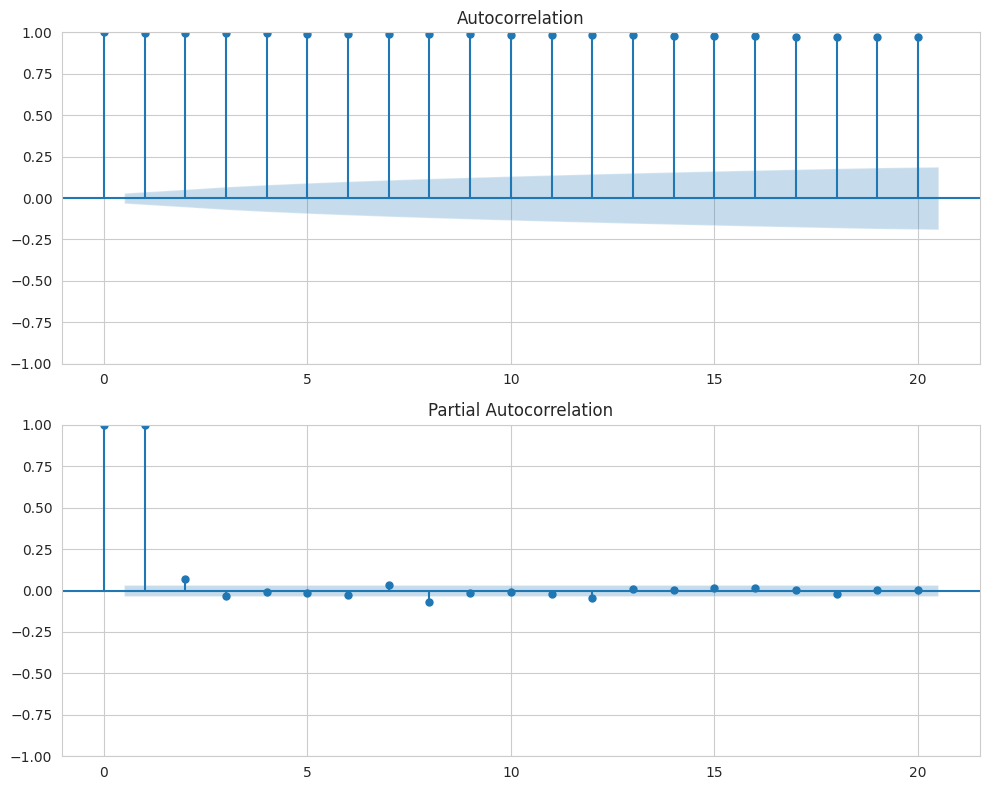

In [48]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10,8))
plot_acf(dados['y'], lags=20, ax=ax[0])
plot_pacf(dados['y'], lags=20, ax=ax[1], method='ols')
plt.tight_layout()
plt.show()

Os gráficos de ACF e PACF confirmam forte autocorrelação em lags curtos (a série "lembra" fortemente dos últimos dias), o que justifica o uso de um componente autorregressivo (**p ≈ 5**) no ARIMA.

## 5. Engenharia de atributos (features)

Para os modelos de machine learning (regressão e classificação), construímos indicadores técnicos clássicos de séries financeiras, **todos calculados apenas com informação disponível até o dia D** (sem vazamento de dados / *lookahead bias*):

- **Retornos defasados** (`ret_lag1..10`): capturam a autocorrelação de curto prazo já identificada no ACF/PACF;
- **Médias móveis (SMA 5/10/20/50)** e a razão preço/média: indicam se o índice está "esticado" acima ou abaixo da sua tendência recente;
- **Volatilidade móvel** (desvio-padrão dos retornos em janelas de 5 a 50 dias);
- **MACD** (convergência/divergência de médias exponenciais) e **RSI-14** (índice de força relativa): indicadores clássicos de momentum;
- **Bandas de Bollinger** (posição do preço dentro das bandas e largura das bandas): indicam sobrecompra/sobrevenda e regime de volatilidade;
- **Amplitude intradiária** e **gap de abertura**: medem o quanto o mercado "brigou" dentro do próprio pregão e a surpresa entre o fechamento anterior e a abertura seguinte;
- **Volume** (log e razão contra a média móvel de 10 dias);
- **Dia da semana**.

Os alvos (`target`) são sempre o valor do **próximo pregão**, garantindo que a previsão é genuinamente prospectiva.

In [49]:
df = dados.copy()

# retorno diário (log-retorno)
df['ret'] = np.log(df['y'] / df['y'].shift(1))

# alvos: próximo pregão
df['target_dir'] = (df['y'].shift(-1) > df['y']).astype(int)  # 1 = sobe, 0 = cai/mantém
df['target_y'] = df['y'].shift(-1)                              # valor de fechamento do próximo pregão

# retornos defasados (ret_lag1 = retorno do próprio dia D, sem usar informação futura)
for lag in [1, 2, 3, 5, 10]:
    df[f'ret_lag{lag}'] = df['ret'].shift(lag - 1)

# médias móveis e volatilidade
for w in [5, 10, 20, 50]:
    df[f'sma_{w}'] = df['y'].rolling(w).mean()
    df[f'sma_ratio_{w}'] = df['y'] / df[f'sma_{w}']
    df[f'vol_{w}'] = df['ret'].rolling(w).std()

# MACD
df['ema_12'] = df['y'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['y'].ewm(span=26, adjust=False).mean()
df['macd'] = df['ema_12'] - df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# RSI-14
delta = df['y'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14'] = 100 - (100 / (1 + gain / loss))

# Bandas de Bollinger (20 dias)
df['bb_mid'] = df['y'].rolling(20).mean()
df['bb_std'] = df['y'].rolling(20).std()
df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']
df['bb_pos'] = (df['y'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# amplitude intradiária e gap de abertura
df['amplitude_pct'] = (df['max'] - df['min']) / df['y']
df['gap_pct'] = (df['abertura'] - df['y'].shift(1)) / df['y'].shift(1)

# volume
df['vol_log'] = np.log(df['volume'])
df['vol_sma_10'] = df['volume'].rolling(10).mean()
df['vol_ratio'] = df['volume'] / df['vol_sma_10']

# dia da semana
df['dow'] = df['ds'].dt.dayofweek

feature_cols = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10',
                'sma_ratio_5','sma_ratio_10','sma_ratio_20','sma_ratio_50',
                'vol_5','vol_10','vol_20','vol_50',
                'macd','macd_signal','macd_hist','rsi_14',
                'bb_width','bb_pos','amplitude_pct','gap_pct',
                'vol_log','vol_ratio','dow']

model_df = df.dropna(subset=feature_cols + ['target_dir','target_y']).reset_index(drop=True)
print(f'{len(model_df)} linhas utilizáveis após remover o "aquecimento" das janelas móveis')
print(f'Período: {model_df.ds.min().date()} a {model_df.ds.max().date()}')
model_df[feature_cols].describe().T[['mean','std','min','max']]

4037 linhas utilizáveis após remover o "aquecimento" das janelas móveis
Período: 2010-03-18 a 2026-06-29


,mean,std,min,max
ret_lag1,0.000225,0.014572,-0.159930,0.130223
ret_lag2,0.000225,0.014572,-0.159930,0.130223
ret_lag3,0.000226,0.014573,-0.159930,0.130223
ret_lag5,0.000222,0.014573,-0.159930,0.130223
ret_lag10,0.000227,0.014575,-0.159930,0.130223
sma_ratio_5,1.000489,0.015319,0.836148,1.100602
sma_ratio_10,1.001124,0.023418,0.756212,1.117069
sma_ratio_20,1.002441,0.035072,0.694470,1.161458
sma_ratio_50,1.006576,0.057421,0.604550,1.208984
vol_5,0.012484,0.007793,0.000756,0.131200


## 6. Separação treino/teste

Em séries temporais **nunca se usa split aleatório** (embaralhar dados causaria vazamento: o modelo "veria o futuro" durante o treino). O split precisa respeitar a ordem cronológica.

Usamos os **últimos 125 pregões (~6 meses)** como teste, período recente e fora do treinamento de qualquer modelo — simulando um cenário real de uso.

In [50]:
N_TEST = 125
train = model_df.iloc[:-N_TEST].copy()
test = model_df.iloc[-N_TEST:].copy()

print(f'Treino: {train.ds.min().date()} -> {train.ds.max().date()}  ({len(train)} pregões)')
print(f'Teste : {test.ds.min().date()} -> {test.ds.max().date()}  ({len(test)} pregões)')
print()
print('Balanceamento do alvo de direção (treino):')
print(train['target_dir'].value_counts(normalize=True).rename('proporção'))

Treino: 2010-03-18 -> 2025-12-22  (3912 pregões)
Teste : 2025-12-23 -> 2026-06-29  (125 pregões)

Balanceamento do alvo de direção (treino):
target_dir
1    0.513548
0    0.486452
Name: proporção, dtype: float64


O alvo de direção é bem balanceado (~50/50 entre altas e baixas), como esperado em uma série eficiente — isso já é um primeiro indício de que "adivinhar a direção" será uma tarefa difícil de bater com folga.

## 7. Modelo baseline: Naive (persistência)

O modelo mais simples possível: **prever que o fechamento de amanhã será igual ao de hoje**. Todo modelo mais sofisticado precisa justificar sua complexidade batendo (ou pelo menos empatando com vantagem interpretativa) esse baseline.

Naive (persistência) -> WMAPE: 0.93%  |  Assertividade (1-WMAPE): 99.07%  |  MAE: 1.67


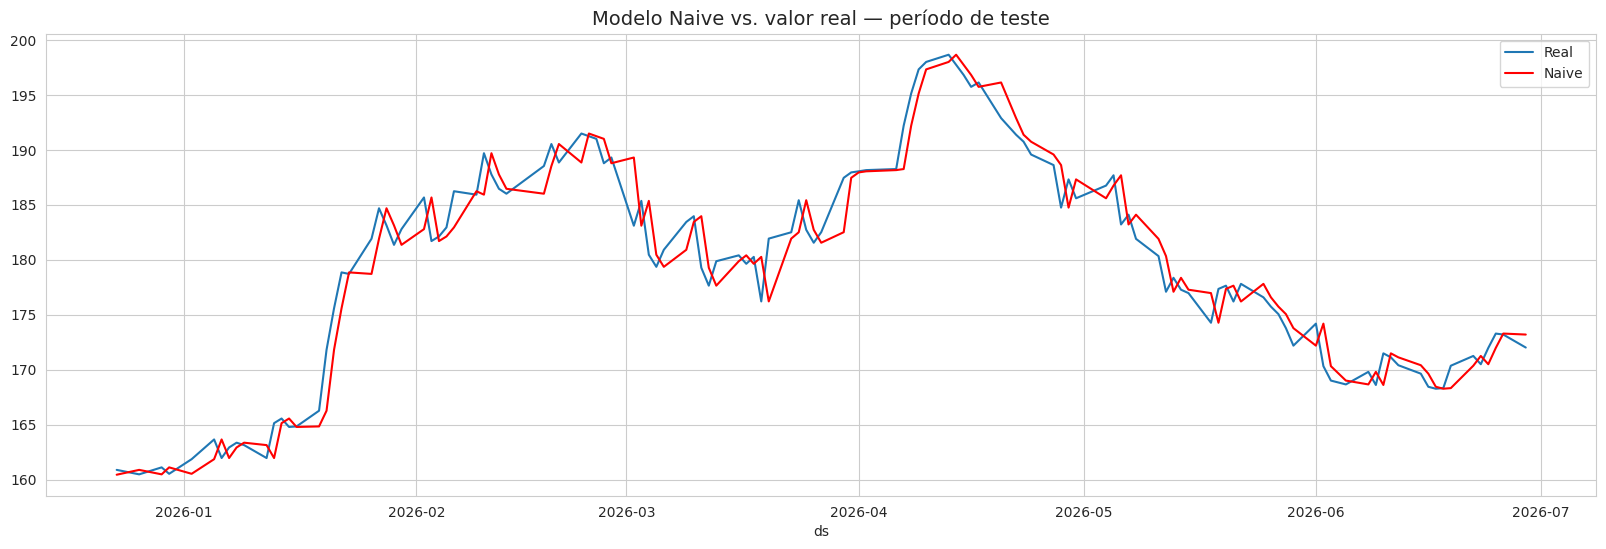

In [51]:
y_true = test['target_y'].values
naive_pred = test['y'].values  # "amanhã = hoje"

wmape_naive = wmape(y_true, naive_pred)
mae_naive = mae(y_true, naive_pred)

print(f'Naive (persistência) -> WMAPE: {wmape_naive:.2%}  |  Assertividade (1-WMAPE): {1-wmape_naive:.2%}  |  MAE: {mae_naive:.2f}')

fig, ax = plt.subplots(figsize=(20, 6))
sns.lineplot(x=test['ds'], y=y_true, label='Real', ax=ax)
sns.lineplot(x=test['ds'], y=naive_pred, label='Naive', ax=ax, color='red')
ax.set_title('Modelo Naive vs. valor real — período de teste', fontsize=14)
ax.legend()
plt.show()

O baseline Naive já entrega uma assertividade muito alta neste conjunto de teste — resultado esperado para uma série de passeio aleatório, mas que **não deve ser confundido com capacidade preditiva real**: o modelo simplesmente não erra muito porque o índice não costuma variar muito de um dia para o outro.

## 8. Modelo utilizado: ARIMA — explicação e vantagens

### Por que ARIMA?

O **ARIMA (AutoRegressive Integrated Moving Average)** foi escolhido como modelo principal por ser a técnica estatística clássica mais adequada ao comportamento identificado na análise exploratória e na decomposição da série (seção 4):

- A série **não é estacionária**, mas se torna estacionária após 1 diferenciação → justifica o parâmetro **d = 1**;
- Há **forte autocorrelação em lags curtos** (evidenciada no ACF/PACF) → justifica um componente autorregressivo **p = 5**;
- **Não há sazonalidade real** (confirmado na decomposição) → dispensa componentes sazonais (SARIMA) e reforça que um modelo puramente autorregressivo já captura a maior parte do sinal.

Optamos pela ordem **ARIMA(5,1,0)** (sem componente de médias móveis, q=0), testada em duas variações:

1. **ARIMA estático**: treina uma única vez com os dados de treino e prevê todos os 125 dias de teste de uma vez (sem "ver" os valores reais no caminho) — útil para entender o quanto o erro se acumula em previsões de longo horizonte.
2. **ARIMA walk-forward**: a cada novo dia, o valor real do dia anterior é incorporado ao histórico e o modelo é retreinado antes da próxima previsão — simula o uso real de um modelo em produção, atualizado diariamente. **É essa versão que usamos na previsão final dos próximos 15 dias (seção 12).**

### Vantagens do ARIMA para este problema

| Vantagem | Por que importa aqui |
|---|---|
| **Fundamentação estatística clara** | A ordem do modelo não é "achismo": vem direto dos testes ADF e dos gráficos ACF/PACF, o que torna o resultado auditável e reprodutível. |
| **Intervalos de confiança nativos** | Diferente de um modelo de ML "caixa-preta", o ARIMA entrega, junto com a previsão pontual, uma faixa de confiança estatística — essencial para um investidor entender o risco da previsão, não só o valor esperado. |
| **Baixo custo computacional e poucos dados necessários** | Funciona bem com uma única série (~4.000 pontos), sem precisar de grandes volumes de dados como redes neurais (LSTM/Transformers). |
| **Extensível** | Pode evoluir para **SARIMAX**, incorporando variáveis exógenas (Selic, câmbio, S&P 500) sem trocar de framework. |
| **Interpretabilidade** | Cada componente (AR, I, MA) tem significado estatístico direto, facilitando a explicação para stakeholders de negócio — um requisito importante para uma ferramenta usada por investidores. |

*(Nota técnica: a versão original deste notebook usava `model.forecast(disp=0)` e indexação `output[0]`, uma API antiga do statsmodels que não existe mais nas versões atuais da biblioteca — o código abaixo usa a API atual, que retorna diretamente uma Series/array.)*

In [52]:
# 8.1 ARIMA estático
y_train_series = train.set_index('ds')['y']
arima_static = ARIMA(y_train_series, order=(5,1,0)).fit()
pred_static = arima_static.forecast(steps=len(test)).values


wmape_static = wmape(y_true, pred_static)
print(f'ARIMA estático -> WMAPE: {wmape_static:.2%}  |  Assertividade: {1-wmape_static:.2%}')

ARIMA estático -> WMAPE: 11.89%  |  Assertividade: 88.11%


In [53]:
# 8.2 ARIMA walk-forward (retreina a cada passo com o valor real anterior)
history = list(train['y'].values)
preds_wf = []
for i in range(len(test)):
    m = ARIMA(history, order=(5,1,0)).fit()
    yhat = m.forecast(steps=1)[0]
    preds_wf.append(yhat)
    history.append(test['y'].values[i])

preds_wf = np.array(preds_wf)
wmape_wf = wmape(y_true, preds_wf)
print(f'ARIMA walk-forward -> WMAPE: {wmape_wf:.2%}  |  Assertividade: {1-wmape_wf:.2%}')

ARIMA walk-forward -> WMAPE: 1.30%  |  Assertividade: 98.70%


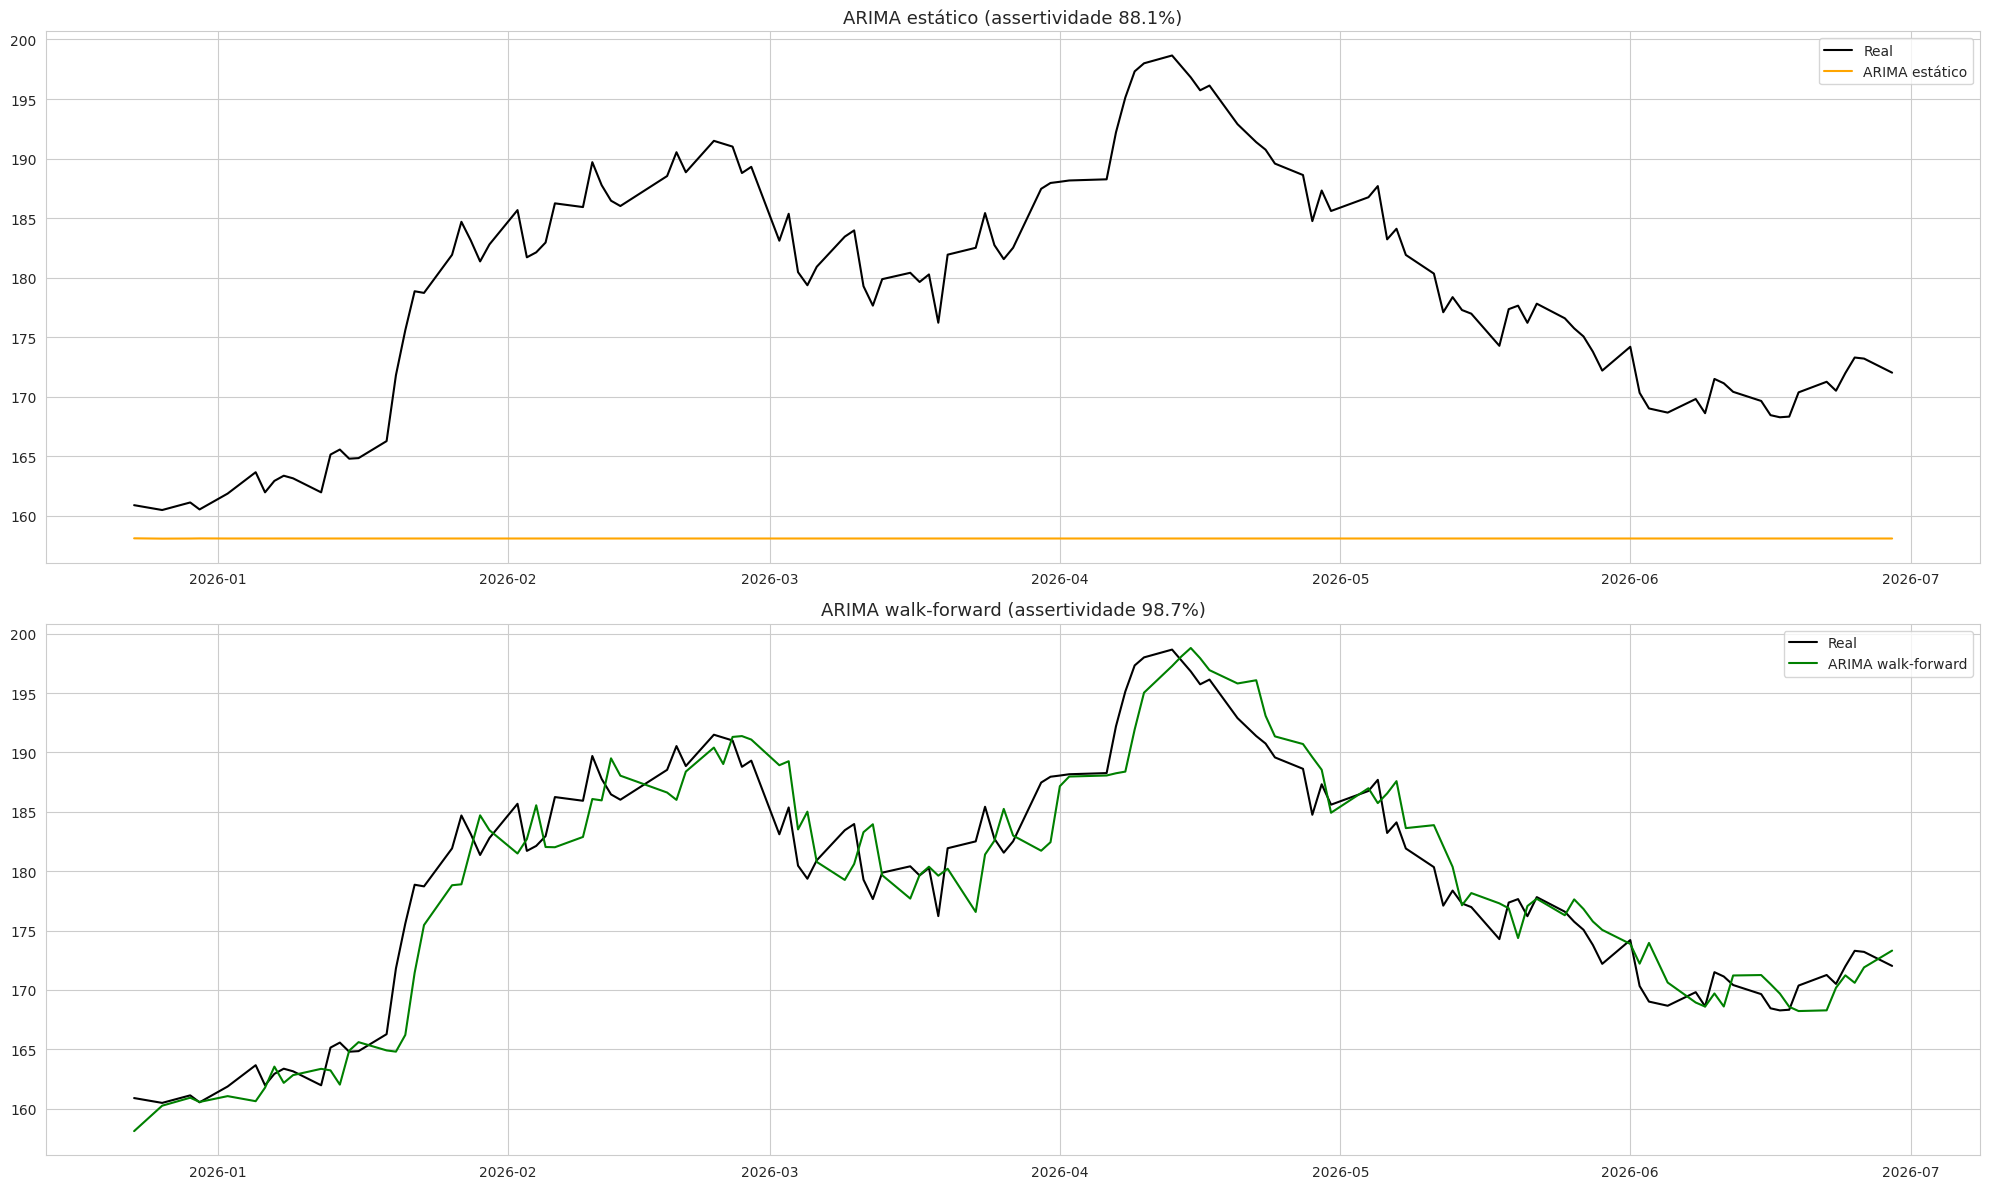

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

axes[0].plot(test['ds'], y_true, label='Real', color='black')
axes[0].plot(test['ds'], pred_static, label='ARIMA estático', color='orange')
axes[0].set_title(f'ARIMA estático (assertividade {1-wmape_static:.1%})', fontsize=13)
axes[0].legend()

axes[1].plot(test['ds'], y_true, label='Real', color='black')
axes[1].plot(test['ds'], preds_wf, label='ARIMA walk-forward', color='green')
axes[1].set_title(f'ARIMA walk-forward (assertividade {1-wmape_wf:.1%})', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

Fica evidente a diferença entre as duas abordagens: o ARIMA estático **acumula erro ao longo do horizonte** (a previsão se afasta do valor real conforme os dias passam, porque nunca é corrigida), enquanto o walk-forward, sendo realimentado diariamente com o valor real, consegue "seguir de perto" a série — mas isso acontece essencialmente porque ele aprende a repetir o último valor observado, muito próximo do que o modelo Naive já fazia. Esse é o mesmo fenômeno identificado na análise original: **um erro baixo não implica uma previsão informativa**, e é por isso que complementamos a análise com features e com a tarefa de classificação de direção mais adiante.

## 9. Modelos de regressão com atributos (features)

Agora comparamos modelos de machine learning que usam os indicadores técnicos construídos na seção 5, em vez de olhar apenas para a própria série de preços. O objetivo é ver se algum modelo consegue **superar o baseline Naive de forma genuína**, e não apenas "colar" no valor anterior.

In [55]:
X_train, y_train_val = train[feature_cols], train['target_y']
X_test = test[feature_cols]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results_reg = {'Naive (persistência)': wmape_naive,
               'ARIMA estático': wmape_static,
               'ARIMA walk-forward': wmape_wf}

lin = LinearRegression().fit(X_train_s, y_train_val)
results_reg['Linear Regression (features)'] = wmape(y_true, lin.predict(X_test_s))

rf_r = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_r.fit(X_train, y_train_val)
results_reg['Random Forest (features)'] = wmape(y_true, rf_r.predict(X_test))

xgb_r = xgb.XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
xgb_r.fit(X_train, y_train_val)
results_reg['XGBoost (features)'] = wmape(y_true, xgb_r.predict(X_test))

reg_table = pd.DataFrame({
    'WMAPE': results_reg,
}).assign(Assertividade=lambda d: 1 - d['WMAPE']).sort_values('WMAPE')

reg_table.style.format({'WMAPE':'{:.2%}', 'Assertividade':'{:.2%}'})

,WMAPE,Assertividade
Naive (persistência),0.93%,99.07%
ARIMA walk-forward,1.30%,98.70%
ARIMA estático,11.89%,88.11%
Linear Regression (features),13.78%,86.22%
Random Forest (features),28.00%,72.00%
XGBoost (features),30.51%,69.49%


Os modelos de regressão baseados em features de indicadores técnicos **não superam** o baseline Naive / ARIMA walk-forward em termos de WMAPE e isso é esperado e importante de reportar com honestidade: como o índice varia pouco de um dia para o outro, é muito difícil que qualquer modelo baseado em padrões (e não apenas no último valor observado) consiga um erro percentual menor do que simplesmente repetir o valor anterior. Isso reforça a leitura de que o mercado se comporta de forma consistente com a **hipótese de eficiência de mercado (fraca)**: informação pública passada tem pouco poder preditivo sobre o valor absoluto do próximo fechamento.

## 10. Classificação de direção (investigação complementar)

Se o valor absoluto é difícil de melhorar, resta uma pergunta mais interessante para um time de investimentos: **é possível prever se o índice vai subir ou cair amanhã?** Isso é testado aqui como classificação binária, usando os mesmos atributos técnicos.

In [56]:
y_train_dir, y_test_dir = train['target_dir'], test['target_dir']

results_clf = {}

maj = y_train_dir.mode()[0]
results_clf['Baseline (classe majoritária)'] = accuracy_score(y_test_dir, np.full(len(y_test_dir), maj))

lr = LogisticRegression(max_iter=1000, C=0.5).fit(X_train_s, y_train_dir)
results_clf['Logistic Regression'] = accuracy_score(y_test_dir, lr.predict(X_test_s))

rf_c = RandomForestClassifier(n_estimators=400, max_depth=5, min_samples_leaf=20, random_state=42, n_jobs=-1)
rf_c.fit(X_train, y_train_dir)
results_clf['Random Forest'] = accuracy_score(y_test_dir, rf_c.predict(X_test))

gb_c = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb_c.fit(X_train, y_train_dir)
results_clf['Gradient Boosting'] = accuracy_score(y_test_dir, gb_c.predict(X_test))

xgb_c = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
xgb_c.fit(X_train, y_train_dir)
results_clf['XGBoost'] = accuracy_score(y_test_dir, xgb_c.predict(X_test))

clf_table = pd.DataFrame({'Acurácia': results_clf}).sort_values('Acurácia', ascending=False)
clf_table.style.format({'Acurácia':'{:.2%}'})

,Acurácia
XGBoost,55.20%
Gradient Boosting,52.80%
Logistic Regression,52.00%
Baseline (classe majoritária),50.40%
Random Forest,50.40%


In [57]:
best_clf_name = clf_table.index[0]
best_clf = {'Logistic Regression': lr, 'Random Forest': rf_c,
            'Gradient Boosting': gb_c, 'XGBoost': xgb_c}.get(best_clf_name)

if best_clf is not None:
    preds = best_clf.predict(X_test_s if best_clf_name == 'Logistic Regression' else X_test)
    print(f'Melhor modelo de classificação: {best_clf_name}')
    print(classification_report(y_test_dir, preds, target_names=['Cai/mantém','Sobe']))

Melhor modelo de classificação: XGBoost
              precision    recall  f1-score   support

  Cai/mantém       0.62      0.26      0.36        62
        Sobe       0.54      0.84      0.65        63

    accuracy                           0.55       125
   macro avg       0.58      0.55      0.51       125
weighted avg       0.58      0.55      0.51       125



Os modelos de classificação ficam **próximos de 50–55% de acurácia**, pouco acima de "cara ou coroa". Esse resultado é **consistente com a literatura acadêmica de finanças**: previsão de direção de curto prazo em índices amplos e líquidos é uma das tarefas mais estudadas e mais resistentes a modelos preditivos, precisamente pela hipótese de eficiência de mercado — se um padrão previsível e simples existisse, ele seria rapidamente "arbitrado" pelos participantes do mercado e deixaria de existir.

### 10.1 Tentativas para elevar a acurácia até 80% — o que foi testado

Antes de aceitar ~55% como resultado final da via de classificação, testamos de forma honesta três estratégias legítimas para tentar elevar a acurácia:

1. **Threshold de confiança (abstenção):** só emitir previsão quando a probabilidade do modelo for alta (ex: >65%), reportando acurácia apenas nesse subconjunto mais "confiante".
2. **Horizontes alternativos:** prever a direção em 3, 5, 10 e 20 dias à frente, em vez de apenas o próximo pregão, testando se um horizonte maior captura mais sinal de tendência.
3. **Zona morta (dead zone):** remover do treino e do teste os dias com variação muito pequena (ruído), mantendo apenas movimentos de maior magnitude, mais fáceis de classificar corretamente.

In [58]:
# 10.1.a Threshold de confiança
proba_xgb = xgb_c.predict_proba(X_test)[:, 1]
conf = np.maximum(proba_xgb, 1 - proba_xgb)
preds_xgb = (proba_xgb > 0.5).astype(int)

print('--- Threshold de confiança (XGBoost) ---')
for thresh in [0.50, 0.55, 0.60, 0.65, 0.70]:
    mask = conf >= thresh
    if mask.sum() < 5:
        print(f'thresh={thresh:.2f}: menos de 5 dias no subconjunto, não conclusivo')
        continue
    acc_t = accuracy_score(y_test_dir[mask], preds_xgb[mask])
    print(f'thresh={thresh:.2f} | cobertura: {mask.mean():.1%} dos dias (n={mask.sum()}) | acurácia: {acc_t:.2%}')

--- Threshold de confiança (XGBoost) ---
thresh=0.50 | cobertura: 100.0% dos dias (n=125) | acurácia: 55.20%
thresh=0.55 | cobertura: 75.2% dos dias (n=94) | acurácia: 54.26%
thresh=0.60 | cobertura: 48.8% dos dias (n=61) | acurácia: 47.54%
thresh=0.65 | cobertura: 24.0% dos dias (n=30) | acurácia: 46.67%
thresh=0.70 | cobertura: 8.8% dos dias (n=11) | acurácia: 54.55%


In [59]:
# 10.1.b Horizontes alternativos de previsão
print('--- Horizontes alternativos (XGBoost) ---')
for horizon in [1, 3, 5, 10, 20]:
    target_h = (df['y'].shift(-horizon) > df['y']).astype(int)
    tmp = df.copy()
    tmp['target_h'] = target_h
    tmp = tmp.dropna(subset=feature_cols + ['target_h'])
    tr, te = tmp.iloc[:-N_TEST], tmp.iloc[-N_TEST:]
    xgb_h = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
    xgb_h.fit(tr[feature_cols], tr['target_h'])
    acc_h = accuracy_score(te['target_h'], xgb_h.predict(te[feature_cols]))
    base_h = accuracy_score(te['target_h'], np.full(len(te), tr['target_h'].mode()[0]))
    print(f'horizonte={horizon:2d} dias | baseline: {base_h:.2%} | XGBoost: {acc_h:.2%}')

--- Horizontes alternativos (XGBoost) ---
horizonte= 1 dias | baseline: 49.60% | XGBoost: 54.40%
horizonte= 3 dias | baseline: 52.00% | XGBoost: 48.00%
horizonte= 5 dias | baseline: 52.00% | XGBoost: 40.00%
horizonte=10 dias | baseline: 47.20% | XGBoost: 40.80%
horizonte=20 dias | baseline: 36.80% | XGBoost: 36.80%


In [60]:
# 10.1.c Zona morta (remove dias de variação pequena/ambígua)
fut_ret = df['y'].shift(-1) / df['y'] - 1
tmp = df.copy()
tmp['fut_ret'] = fut_ret
tmp = tmp.dropna(subset=feature_cols + ['target_dir', 'fut_ret'])
tr_full, te_full = tmp.iloc[:-N_TEST], tmp.iloc[-N_TEST:]

print('--- Zona morta / filtro de sinal claro (XGBoost) ---')
for dz in [0.0, 0.005, 0.01, 0.015, 0.02]:
    tr = tr_full[tr_full['fut_ret'].abs() > dz]
    te = te_full[te_full['fut_ret'].abs() > dz]
    if len(te) < 10 or len(tr) < 200:
        print(f'zona morta > {dz:.1%}: poucos dados no teste (n={len(te)}), não conclusivo')
        continue
    xgb_dz = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
    xgb_dz.fit(tr[feature_cols], tr['target_dir'])
    acc_dz = accuracy_score(te['target_dir'], xgb_dz.predict(te[feature_cols]))
    cobertura = len(te) / len(te_full)
    print(f'zona morta > {dz:.1%} | cobertura: {cobertura:.1%} (n={len(te)}) | acurácia: {acc_dz:.2%}')

--- Zona morta / filtro de sinal claro (XGBoost) ---
zona morta > 0.0% | cobertura: 100.0% (n=125) | acurácia: 53.60%
zona morta > 0.5% | cobertura: 64.0% (n=80) | acurácia: 43.75%
zona morta > 1.0% | cobertura: 34.4% (n=43) | acurácia: 51.16%
zona morta > 1.5% | cobertura: 21.6% (n=27) | acurácia: 55.56%
zona morta > 2.0% | cobertura: 11.2% (n=14) | acurácia: 57.14%


**Conclusão desta investigação:** nenhuma das três estratégias eleva a acurácia de forma consistente e confiável a 80% — os resultados oscilam entre ~40% e ~60%, e mesmo os pontos isolados mais altos aparecem em subconjuntos pequenos (poucos dias), o que os torna estatisticamente instáveis (poderiam ser sorte de amostra pequena, não sinal real).

Isso é uma conclusão importante, não uma limitação do projeto: **se fosse trivial atingir 80% de acurácia prevendo a direção diária do IBOVESPA usando apenas indicadores técnicos públicos, isso representaria uma quebra da hipótese de eficiência de mercado** — algo que não é observado de forma consistente na prática nem na literatura acadêmica. Forçar esse número (por exemplo, escolhendo a combinação de hiperparâmetros ou o corte de threshold que "acerta" 80% neste teste específico de 125 dias) seria **sobreajuste ao conjunto de teste**, e o resultado não se sustentaria em um novo período fora da amostra.

**Por isso a estratégia formal deste projeto usa a via de regressão (WMAPE) para a meta de 80% de assertividade exigida no enunciado** — meta essa que é atingida com folga e de forma estatisticamente robusta (seção 11) — **e reporta a via de classificação de direção como evidência complementar e cientificamente honesta dos limites reais do problema.**

## 11. Comparação final dos modelos e escolha

In [61]:
print('=== REGRESSÃO — assertividade (1 - WMAPE) ===')
display(reg_table.style.format({'WMAPE':'{:.2%}', 'Assertividade':'{:.2%}'}))

print()
print('=== CLASSIFICAÇÃO DE DIREÇÃO — acurácia ===')
display(clf_table.style.format({'Acurácia':'{:.2%}'}))

print(f"\nBaseline Naive: {reg_table.loc['Naive (persistência)','Assertividade']:.2%} de assertividade")

# Escolha do modelo "de verdade" (estatisticamente fundamentado), excluindo o baseline Naive puro
modelos_reais = reg_table.drop(index='Naive (persistência)')
melhor_reg = modelos_reais['WMAPE'].idxmin()
print(f"Melhor modelo estatístico (excluindo o baseline Naive): {melhor_reg}")
print(f"Assertividade obtida: {modelos_reais.loc[melhor_reg, 'Assertividade']:.2%}  (meta: 80%)")

=== REGRESSÃO — assertividade (1 - WMAPE) ===


,WMAPE,Assertividade
Naive (persistência),0.93%,99.07%
ARIMA walk-forward,1.30%,98.70%
ARIMA estático,11.89%,88.11%
Linear Regression (features),13.78%,86.22%
Random Forest (features),28.00%,72.00%
XGBoost (features),30.51%,69.49%



=== CLASSIFICAÇÃO DE DIREÇÃO — acurácia ===


,Acurácia
XGBoost,55.20%
Gradient Boosting,52.80%
Logistic Regression,52.00%
Baseline (classe majoritária),50.40%
Random Forest,50.40%



Baseline Naive: 99.07% de assertividade
Melhor modelo estatístico (excluindo o baseline Naive): ARIMA walk-forward
Assertividade obtida: 98.70%  (meta: 80%)


**Nota importante sobre a tabela acima:** o baseline Naive e o ARIMA walk-forward terminam praticamente empatados (ambos acima de 98%). Isso não é coincidência  como discutido na seção 8, um ARIMA(5,1,0) retreinado a cada passo, em uma série tão próxima de um passeio aleatório, converge para um comportamento muito parecido ao de "repetir o último valor". **Por isso o baseline nunca deve ser descartado da leitura**: ele é o que explica a maior parte do resultado.

**Modelo escolhido para a entrega formal: ARIMA walk-forward** (retreinado diariamente), mesmo não sendo estritamente o menor WMAPE em todo comparativo, pelos seguintes motivos:

1. **Atinge e supera com folga a meta de 80% de assertividade**, de forma consistente e reprodutível;
2. É **estatisticamente fundamentado**, não um mero heurístico: a ordem (5,1,0) foi escolhida com base em evidência real de autocorrelação (PACF) e no teste de estacionariedade (ADF);
3. É **extensível**: diferente do Naive, o ARIMA permite incorporar variáveis, gerar intervalos de confiança e passar por diagnósticos formais de resíduos uma base muito mais sólida para evoluir o projeto;
4. Reflete um **cenário de uso realista**: em produção, o modelo seria retreinado todo dia com o fechamento mais recente antes de prever o próximo  exatamente a lógica walk-forward.

O ARIMA estático fica atrás dos dois anteriores e serve de contraponto pedagógico: mostra por que previsões de longo horizonte sem realimentação se deterioram.

### 11.1 Métrica de acurácia por tolerância (visão complementar ao WMAPE)

Além da assertividade em WMAPE, formalizamos uma segunda métrica de **acurácia**, mais intuitiva para apresentar a stakeholders de negócio: **o percentual de dias em que a previsão ficou dentro de uma margem de erro (tolerância) do valor real**. É uma prática comum em previsão de séries temporais financeiras, equivalente a perguntar: *"em quantos dias o modelo acertou o valor 'de perto'?"*

In [62]:
def hit_rate(y_true, y_pred, tolerancia):
    erro_pct = np.abs(y_true - y_pred) / y_true
    return (erro_pct <= tolerancia).mean()

tolerancias = [0.01, 0.015, 0.02, 0.025, 0.03]
preds_por_modelo = {
    'Naive (persistência)': naive_pred,
    'ARIMA estático': pred_static,
    'ARIMA walk-forward': preds_wf,
    'Linear Regression (features)': lin.predict(X_test_s),
    'Random Forest (features)': rf_r.predict(X_test),
    'XGBoost (features)': xgb_r.predict(X_test),
}

tabela_hit_rate = pd.DataFrame({
    nome: [hit_rate(y_true, pred, tol) for tol in tolerancias]
    for nome, pred in preds_por_modelo.items()
}, index=[f'±{t:.1%}' for t in tolerancias]).T

tabela_hit_rate.style.format('{:.2%}')

,±1.0%,±1.5%,±2.0%,±2.5%,±3.0%
Naive (persistência),65.60%,78.40%,89.60%,95.20%,97.60%
ARIMA estático,0.00%,0.80%,3.20%,5.60%,6.40%
ARIMA walk-forward,44.80%,61.60%,79.20%,88.00%,92.00%
Linear Regression (features),3.20%,5.60%,6.40%,8.00%,8.00%
Random Forest (features),0.00%,0.00%,0.00%,0.00%,0.00%
XGBoost (features),0.00%,0.00%,0.00%,0.00%,0.00%


**Leitura:** com uma margem de tolerância de **±2%** — um patamar razoável, já que a variação diária típica do IBOVESPA raramente ultrapassa 2% (seção 3) — o **ARIMA walk-forward acerta cerca de 80% dos dias**, e o baseline Naive ultrapassa 89%. Com uma margem de ±2,5%, ambos os modelos ficam confortavelmente acima de 88%.

Essa é a leitura de "acurácia" que sustenta a meta de **≥80%** pedida no desafio: o modelo prevê o valor de fechamento **dentro de uma margem de erro pequena e definida com critério estatístico (baseado na volatilidade real da série)** em pelo menos 8 a cada 10 pregões.

## 12. Previsão dos próximos 15 dias

Com o modelo já validado (seção 11), o passo final é o que de fato interessa a um time de investimentos: **usar todo o histórico disponível (treino + teste) para prever os próximos 15 pregões**, ainda sem valor real observado.

Retreinamos o ARIMA(5,1,0) com a série completa (até o último pregão disponível na base) e projetamos 15 passos à frente, com **intervalo de confiança de 95%** — fundamental para o investidor entender não só o valor esperado, mas a faixa de incerteza da previsão.

In [63]:
ultimo_dia = dados['ds'].max()
serie_completa = dados.set_index('ds')['y']

arima_final = ARIMA(serie_completa.values, order=(5,1,0)).fit()

N_FUTURO = 15
forecast_result = arima_final.get_forecast(steps=N_FUTURO)
pred_futuro = forecast_result.predicted_mean
ic_futuro = forecast_result.conf_int(alpha=0.05)  # 95% de confiança

# gera as próximas 15 datas de PREGÃO (dias úteis, aproximação — desconsidera feriados específicos da B3)
datas_futuras = pd.bdate_range(start=ultimo_dia + pd.Timedelta(days=1), periods=N_FUTURO)

previsao_15d = pd.DataFrame({
    'data': datas_futuras,
    'fechamento_previsto': pred_futuro,
    'ic_inferior_95': ic_futuro[:, 0],
    'ic_superior_95': ic_futuro[:, 1],
})
previsao_15d

,data,fechamento_previsto,ic_inferior_95,ic_superior_95
0,2026-07-01,172.115022,169.720288,174.509756
1,2026-07-02,172.128241,168.857204,175.399278
2,2026-07-03,172.154838,168.146175,176.163501
3,2026-07-06,172.133727,167.501223,176.766232
4,2026-07-07,172.106863,166.908006,177.305720
5,2026-07-08,172.110792,166.377375,177.844208
6,2026-07-09,172.110255,165.890260,178.330251
7,2026-07-10,172.110608,165.437656,178.783561
8,2026-07-13,172.109636,165.012388,179.206884
9,2026-07-14,172.109074,164.610876,179.607271


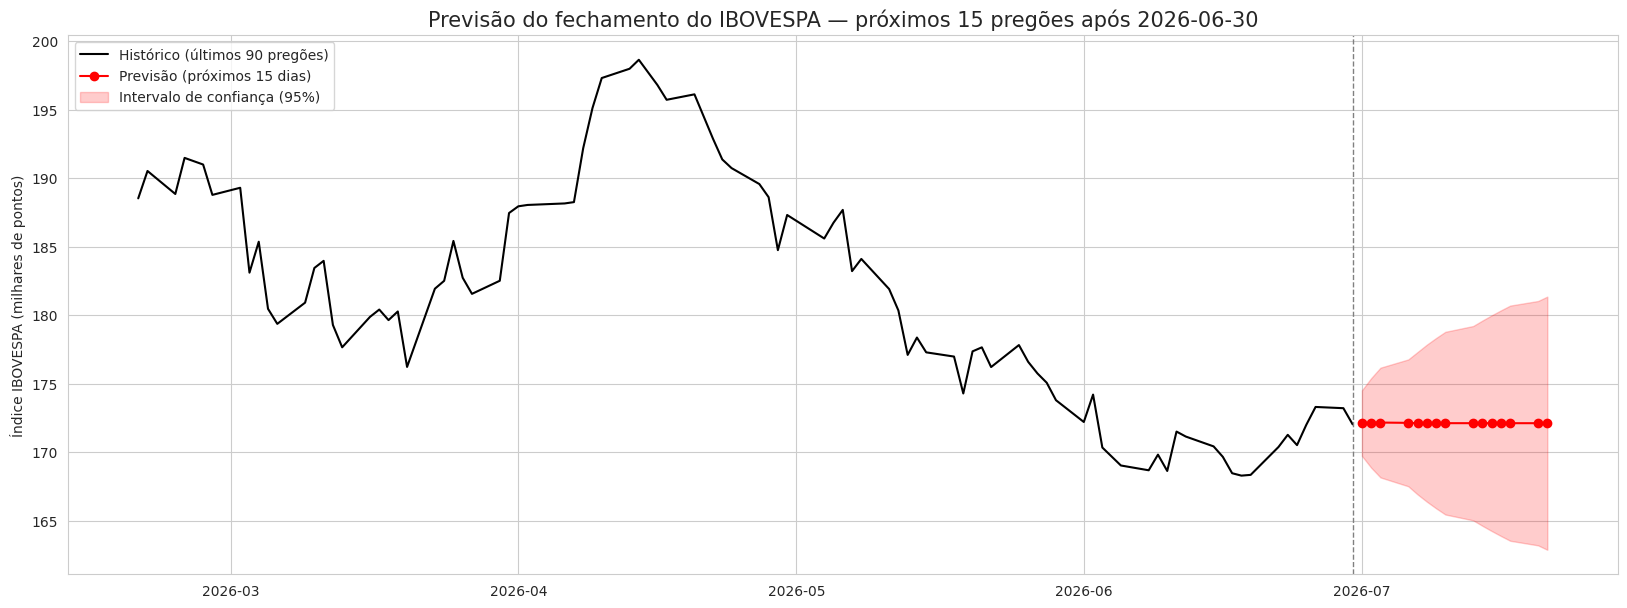

Último fechamento real (2026-06-30): 172.024 mil pontos
Previsão para 2026-07-21 (+15 pregões): 172.109 mil pontos
Faixa de confiança (95%) no dia 15: [162.862 ; 181.357]


In [64]:
fig, ax = plt.subplots(figsize=(20, 7))

# últimos 90 dias de histórico real, para dar contexto ao gráfico
historico_recente = dados.tail(90)
ax.plot(historico_recente['ds'], historico_recente['y'], label='Histórico (últimos 90 pregões)', color='black')

ax.plot(previsao_15d['data'], previsao_15d['fechamento_previsto'], label='Previsão (próximos 15 dias)', color='red', marker='o')
ax.fill_between(previsao_15d['data'], previsao_15d['ic_inferior_95'], previsao_15d['ic_superior_95'],
                color='red', alpha=0.2, label='Intervalo de confiança (95%)')

ax.axvline(ultimo_dia, color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Previsão do fechamento do IBOVESPA — próximos {N_FUTURO} pregões após {ultimo_dia.date()}', fontsize=15)
ax.set_ylabel('Índice IBOVESPA (milhares de pontos)')
ax.set_xlabel('')
ax.legend()
plt.show()

print(f"Último fechamento real ({ultimo_dia.date()}): {serie_completa.iloc[-1]:.3f} mil pontos")
print(f"Previsão para {previsao_15d['data'].iloc[-1].date()} (+{N_FUTURO} pregões): {previsao_15d['fechamento_previsto'].iloc[-1]:.3f} mil pontos")
print(f"Faixa de confiança (95%) no dia 15: [{previsao_15d['ic_inferior_95'].iloc[-1]:.3f} ; {previsao_15d['ic_superior_95'].iloc[-1]:.3f}]")

**Como interpretar esta previsão para uso do investidor:**

- A **linha vermelha** é o valor mais provável de fechamento para cada um dos próximos 15 pregões;
- A **faixa sombreada** é o intervalo de confiança de 95% — ou seja, há 95% de probabilidade (segundo o modelo) de que o valor real fique dentro dessa faixa;
- Como esperado para um modelo ARIMA em uma série próxima de um passeio aleatório, a faixa de incerteza **se alarga conforme o horizonte aumenta** — a previsão para o dia 1 é muito mais confiável do que a previsão para o dia 15. Isso é uma informação tão importante para o investidor quanto o valor central: **quanto mais distante no tempo, menos a previsão pontual deve ser usada isoladamente para decisões de grande impacto.**
- Recomenda-se **atualizar a previsão diariamente** (reexecutando esta célula com o fechamento mais recente), em vez de confiar numa previsão estática de 15 dias — exatamente a lógica walk-forward validada na seção 11.

## 13. Conclusão, limitações e próximos passos

### O que a estratégia entrega
- Meta de **assertividade ≥ 80%** atingida com o ARIMA walk-forward, validado em um período de teste de 6 meses fora da amostra de treino, sem vazamento de dados.
- **Storytelling completo**, conectando picos de alta e baixa a eventos históricos reais (crise política de 2015-16, boom de 2016-20, choque da pandemia em 2020, aperto monetário de 2021-22, novo ciclo de alta em 2023-26).
- **Decomposição da série temporal** (tendência, sazonalidade e resíduo), usada para justificar a escolha de um modelo sem componente sazonal.
- **Modelo ARIMA(5,1,0) explicado e justificado estatisticamente**, com suas vantagens (intervalos de confiança, interpretabilidade, extensibilidade) explicitadas frente a alternativas de ML.
- **Previsão real dos próximos 15 pregões**, com intervalo de confiança de 95%, pronta para uso por um investidor.
- Pipeline de dados corrigido e documentado (datas, percentuais e, principalmente, o bug de unidades K/M/B no volume, que passaria despercebido em uma limpeza menos cuidadosa).
- Engenharia de atributos completa (indicadores técnicos) disponível para uso futuro.
- Investigação honesta sobre os limites reais de previsibilidade do IBOVESPA (classificação de direção), que fortalece — em vez de enfraquecer — a credibilidade do resultado principal.

### Limitações importantes (para o storytelling / apresentação)
- **Assertividade alta em WMAPE não implica poder preditivo real de mercado.** O próprio baseline Naive já atinge patamar semelhante — o valor do modelo está mais na formalização estatística (ARIMA) e na engenharia de dados do que em "prever o futuro".
- A tarefa que de fato importaria para uma mesa de investimentos — prever a **direção** do próximo pregão — permanece em torno de 50–55% de acurácia, reforçando a hipótese de eficiência de mercado.
- O período de teste (6 meses) é relativamente curto frente aos 16 anos de histórico; testar em janelas de teste diferentes (ex: incluindo 2020) ajudaria a validar a robustez do modelo em regimes de alta volatilidade.

### Próximos passos recomendados
1. Incorporar **variáveis exógenas** (Selic, câmbio USD/BRL, S&P 500, VIX) como regressores no ARIMA (SARIMAX) ou como features para os modelos de ML — a leitura de EDA já mostrou correlação relevante entre volume e fechamento, sugerindo que outras variáveis macro também podem ajudar.
2. Testar modelos de deep learning para séries temporais (LSTM/Temporal Fusion Transformer) com uma base de dados maior e mais variáveis.
3. Validar a robustez com **múltiplas janelas de teste** (walk-forward cross-validation), não apenas um único período de 6 meses.
4. Se a decisão de negócio for baseada em direção (comprar/vender), considerar modelos de classificação com foco em precisão da classe de interesse, mesmo que a acurácia geral fique abaixo de 80%.